In [1]:
# Constants
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Constants 
g = 9.81 # (m/s^2)
m = 0.150 # (kg/mass of ball)
b = 0.05 # drag coefficient
e = 0.80 # restitution constant

y_i = 2.0 # intial height
v_i = 0.0 # intial velocity

t_f = 20.0 # total time (s)
v_end = 0.05 # 0.05 > = ball has come to a stop

def ball_drop(t, state, g, m, b): # inital dropping of the ball
    y, v = state

    dydt = v
    dvdt = -g - (b/m)*v**2 # acceleration (with drag)

    return [dydt, dvdt]



In [2]:
def ball_hit_ground(t, state, g, m, b):
    y, v = state
    return y

ball_hit_ground.terminal = True
ball_hit_ground.direction = -1 # event starts when ball is going towards the ground, just about right when it hits

In [3]:
def bouncing_ball(y_i, v_i, g, m, b, e, t_f, v_end):

    t_list = [] # List for time
    y_list = [] # List for position
    v_list = [] # List for velocity
    bounce_t = [] # List for number of bounces
    bounce_v = [] # List for velocity of bounce
    highest_height = [] # List for highest heights following the bounce

    t_start = 0.0
    state = [y_i, v_i]

    while t_start < t_f:

        sol = solve_ivp(
            ball_drop,
            [t_start, t_f], 
            state,
            args=(g, m, b),
            events=ball_hit_ground,
            max_step = 0.01
        )

        t_list.extend(sol.t)
        y_list.extend(sol.y[0])
        v_list.extend(sol.y[1]) # Storing data for each bounce
        highest_height.append(np.max(sol.y[0]))

        if len(sol.t_events[0]) == 0:
            break # Stops the loop if there isn't a bounce

        t_bounce = sol.t_events[0][0]
        v_beforebounce = sol.y_events[0][0][1]
        v_afterbounce = -e*v_beforebounce # computes velocity after a bounce

        bounce_t.append(t_bounce)
        bounce_v.append(v_afterbounce)

        if abs(v_afterbounce) < v_end :
            break  

        t_start = t_bounce
        state = [1e-8, v_afterbounce]

    return np.array(t_list), np.array(y_list), np.array(v_list), np.array(bounce_t), np.array(bounce_v), np.array(highest_height)

        

Number of bounces: 24
Time until rest: 6.825080965830516 seconds


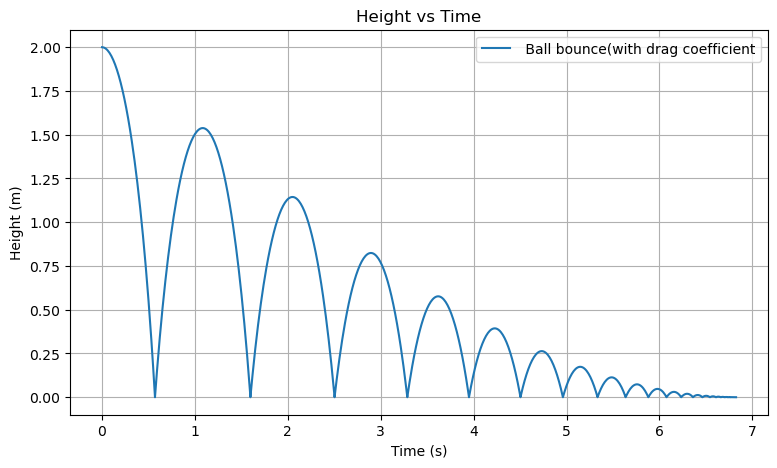

In [4]:
# Height vs Time graph
t, y, v, bounce_t, bounce_v, highest_height = bouncing_ball(
    y_i, v_i, g, m, b, e, t_f, v_end
)

print("Number of bounces:", len(bounce_t))
print("Time until rest:", t[-1], "seconds") # returns last value of time

plt.figure(figsize=(9,5))
plt.plot(t, y, label = " Ball bounce(with drag coefficient")
plt.xlabel("Time (s)")
plt.ylabel("Height (m)")
plt.title("Height vs Time")
plt.legend()
plt.grid(True)
plt.show()

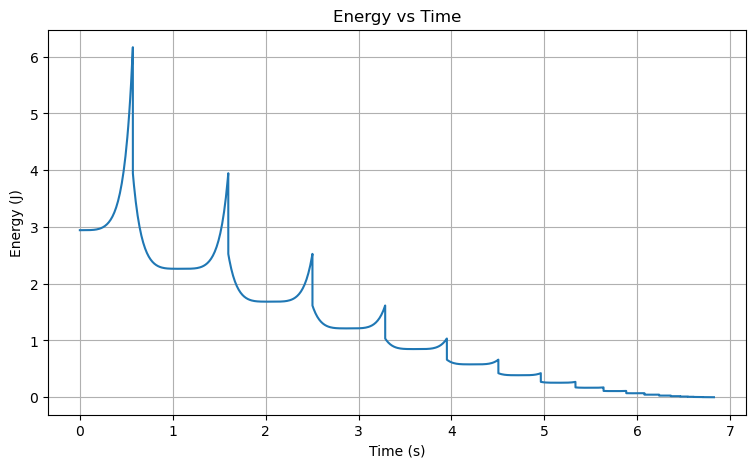

In [5]:
# Energy vs Time
E = 0.5*m*v**2 + m*g*y # Kinetic Energy

plt.figure(figsize=(9,5))
plt.plot(t, E)
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.title("Energy vs Time")
plt.grid(True)
plt.show()

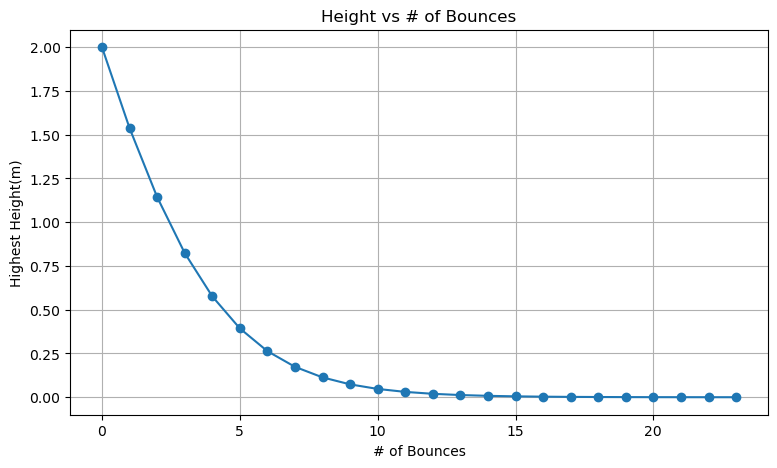

In [6]:
# Height vs Number of Bounces
bounce_n = np.arange(len(highest_height)) # array for bounce numbers

plt.figure(figsize=(9,5))
plt.plot(bounce_n, highest_height, marker="o")
plt.xlabel("# of Bounces")
plt.ylabel("Highest Height(m)")
plt.title("Height vs # of Bounces")
plt.grid(True)
plt.show()

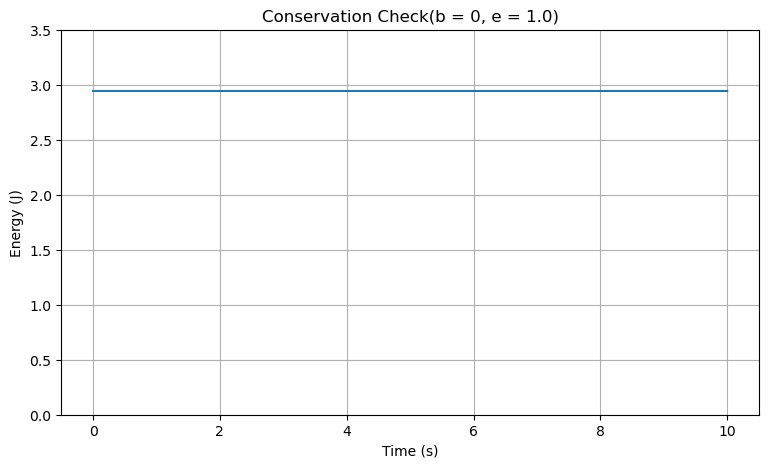

In [8]:
# Conservation Check
b_check = 0.0
e_check = 1.0


t_check, y_check, v_check, bt_check, bs_check, height_check = bouncing_ball(
    y_i, v_i, g, m, b_check, e_check, 10.0, v_end
)


energy_check = 0.5*m*v_check**2 + m*g*y_check # Kinetic Energy

plt.figure(figsize=(9,5))
plt.plot(t_check, energy_check)
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.title("Conservation Check(b = 0, e = 1.0)")
plt.ylim(0,3.5)
plt.grid(True)
plt.show()



In [ ]:
# AI(ChatGPT) had attributions in debugging code and assistance in formulating simulation. 